# Supply Chain Contagion: Does Port Disruption Spread?

Every major port monitoring system watches one port at a time.
This project asks a different question:

**When one port is disrupted, does disruption spread to others — and if so, how fast?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/Ports.csv')
disruption = pd.read_csv('../data/Port_Disruption.csv')

In [3]:
print(f"Ports Shape: {df.shape}")
print(f"Ports Disruption Shape: {disruption.shape}")

Ports Shape: (5149090, 30)
Ports Disruption Shape: (127, 21)


In [4]:
print("Ports Describe\n")
df.describe()

Ports Describe



,year,month,day,portcalls_container,portcalls_dry_bulk,portcalls_general_cargo,portcalls_roro,portcalls_tanker,portcalls_cargo,portcalls,...,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export,ObjectId
count,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,...,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06,5.149090e+06
mean,2.022057e+03,6.446029e+00,1.570586e+01,6.419074e-01,3.906104e-01,5.167129e-01,1.408542e-01,7.828791e-01,1.690085e+00,2.472964e+00,...,1.186691e+04,1.673101e+04,4.683093e+03,6.542037e+03,4.247897e+02,6.935445e+01,4.432966e+03,1.171934e+04,1.615236e+04,2.574546e+06
std,2.041546e+00,3.482911e+00,8.812241e+00,2.536098e+00,1.409944e+00,1.486482e+00,5.997788e-01,2.917218e+00,4.499197e+00,6.658246e+00,...,5.708885e+04,7.156149e+04,3.868197e+04,4.822073e+04,1.768562e+03,5.627120e+02,2.651727e+04,6.385750e+04,7.263588e+04,1.486414e+06
min,2.019000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2.020000e+03,3.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.287273e+06
50%,2.022000e+03,6.000000e+00,1.600000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.574546e+06
75%,2.024000e+03,9.000000e+00,2.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,...,1.291000e+03,3.469000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.480000e+02,2.517000e+03,3.861818e+06
max,2.026000e+03,1.200000e+01,3.100000e+01,7.600000e+01,8.300000e+01,4.300000e+01,1.900000e+01,1.230000e+02,1.770000e+02,2.180000e+02,...,3.376236e+06,3.686732e+06,2.015618e+06,2.641160e+06,8.454700e+04,3.525700e+04,5.248957e+06,2.657613e+06,5.949541e+06,5.149090e+06


In [5]:
print("Ports Disruption\n")
disruption.describe()

Ports Disruption



,eventid,year,lat,long,n_affectedports,ObjectId,Shape__Area,Shape__Length
count,1.270000e+02,127.000000,127.000000,127.000000,127.000000,127.000000,1.270000e+02,1.270000e+02
mean,1.310299e+06,2022.133858,15.965160,47.490588,3.385827,64.007874,5.088037e+11,4.141591e+06
std,1.366545e+06,2.056203,20.865071,87.142215,4.916844,36.819486,6.832424e+11,3.917985e+06
min,1.000000e+06,2018.000000,-36.649250,-178.100000,0.000000,1.000000,2.173469e+06,6.906224e+03
25%,1.000821e+06,2020.000000,10.135956,23.282150,0.000000,32.500000,4.580411e+10,7.653508e+05
50%,1.001124e+06,2023.000000,21.300000,77.719800,2.000000,64.000000,3.044759e+11,3.432525e+06
75%,1.141136e+06,2024.000000,32.400000,109.150000,4.000000,95.500000,6.913571e+11,5.872413e+06
max,1.000000e+07,2026.000000,48.400000,179.800000,29.000000,128.000000,4.640099e+12,2.185619e+07


In [6]:
print(f"Ports columns:\n {df.columns.to_list()}\n")
print(f"Ports Disruptions columns:\n {disruption.columns.to_list()}")

Ports columns:
 ['date', 'year', 'month', 'day', 'portid', 'portname', 'country', 'ISO3', 'portcalls_container', 'portcalls_dry_bulk', 'portcalls_general_cargo', 'portcalls_roro', 'portcalls_tanker', 'portcalls_cargo', 'portcalls', 'import_container', 'import_dry_bulk', 'import_general_cargo', 'import_roro', 'import_tanker', 'import_cargo', 'import', 'export_container', 'export_dry_bulk', 'export_general_cargo', 'export_roro', 'export_tanker', 'export_cargo', 'export', 'ObjectId']

Ports Disruptions columns:
 ['eventid', 'eventtype', 'eventname', 'htmlname', 'htmldescription', 'alertlevel', 'country', 'fromdate', 'year', 'todate', 'severitytext', 'lat', 'long', 'editdate', 'affectedports', 'n_affectedports', 'affectedpopulation', 'pageid', 'ObjectId', 'Shape__Area', 'Shape__Length']


In [7]:
## Date Range - Ports
print(f"Date Range: {df['year'].min()} - {df['year'].max()}")

Date Range: 2019 - 2026


In [8]:
print(f"Unique Ports:\n {df['portname'].nunique()}\n {df.portname.unique().tolist()}")

Unique Ports:
 1965
 ['Tsuruga', 'Sibolga', 'Fangcheng', 'Ube', 'Bluff Harbor', 'Tynemouth', 'Penglai', 'Misrata', 'Khorramshahr', 'Uno', 'Stagen', 'Nowshahr Port', 'Qingdao', 'Uwajima', 'Alexandria', 'Mina Al Ahmadi', 'Wisbech', 'Kitakyushu (Wakamatsu)', 'Dongjiakou', 'As Suways', 'Amsterdam', 'Tanjung Perak', 'Wakayama-Shimotsu', 'Hay Point', 'Workington', 'Qinzhou', 'Gisborne', 'Qinhuangdao', 'Tanah Merah', 'San Giorgio', 'Qiwei', 'Yatsushiro', 'Morehead City', 'Safaga', 'Yawatahama', 'Fuzhou', 'Yokkaichi', 'Quanzhou', 'Tanjung Benete', 'Delfzijl', 'Abidjan', 'Port Said', 'Rizhao', 'Hobart', 'Yokohama', 'Tanjung Geren', 'Yokosuka', 'Damietta', 'Aktau Port', 'San Pedro', 'Bautino', 'Al Adabiyah', 'Abu Dhabi', 'Akureyri', 'Ajman', 'Djupivogur', 'Al Hamriyah LPG Terminal', 'Eskifjordhur', 'Sharjah', 'Reykjavik', 'Dubai', 'Aqaba', 'New Bedford', 'Sanshandaocun', 'Al Fujayrah', 'Shantou', 'Jabal Az Zannah-Ruways', 'Shanghai (Pudong)', 'Khor Fakkan', 'Shekou (Shenzhen)', 'Jebel Ali', 'Shi

In [9]:
print(f"Countries:\n {df['country'].nunique()}\n {df.country.unique().tolist()}")

Countries:
 180
 ['Japan', 'Indonesia', 'China', 'New Zealand', 'United Kingdom', 'Libya', 'Iran', 'Egypt', 'Kuwait', 'The Netherlands', 'Australia', 'Italy', 'United States', "Côte d'Ivoire", 'Kazakhstan', 'United Arab Emirates', 'Iceland', 'Jordan', 'Iraq', 'Syria', 'Spain', 'El Salvador', 'Mexico', 'Norway', 'Russian Federation', 'Algeria', 'Saudi Arabia', 'Madagascar', 'Venezuela', 'Equatorial Guinea', 'Yemen', 'Philippines', 'Morocco', 'Türkiye', 'Cyprus', 'Sweden', 'Denmark', 'Georgia', 'Peru', 'France', 'Dominican Republic', 'Greece', 'Anguilla', 'Portugal', 'New Caledonia', 'Chile', 'Papua New Guinea', 'Saint Martin', 'Croatia', 'Azerbaijan', 'Thailand', 'Brazil', 'Canada', 'Cuba', 'Barbados', 'Cook Islands', 'Belgium', 'Samoa', 'Guam', 'The Gambia', 'Tunisia', 'Panama', 'Israel', 'French Polynesia', 'Montenegro', 'Colombia', 'St.  Kitts and Nevis', 'Vietnam', 'Haiti', 'Finland', 'South Africa', 'St.  Lucia', 'Poland', 'United States Virgin Islands', 'Cayman Islands', 'Taiwan P

In [3]:
df

,date,year,month,day,portid,portname,country,ISO3,portcalls_container,portcalls_dry_bulk,...,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export,ObjectId
0,2019/01/01,2019,1,1,port1325,Tsuruga,Japan,JPN,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2019/01/02,2019,1,2,port1325,Tsuruga,Japan,JPN,0,0,...,0,0,0,0,0,0,0,0,0,2
2,2019/01/03,2019,1,3,port1325,Tsuruga,Japan,JPN,1,0,...,439,439,0,0,0,0,0,0,0,3
3,2019/01/04,2019,1,4,port1325,Tsuruga,Japan,JPN,0,1,...,83913,83913,0,0,0,0,0,0,0,4
4,2019/01/05,2019,1,5,port1325,Tsuruga,Japan,JPN,0,0,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5149085,2026/02/02,2026,2,2,port2429,Taressa,Guinea,GIN,0,1,...,6959,6959,0,0,0,0,0,0,0,5149086
5149086,2026/02/03,2026,2,3,port2429,Taressa,Guinea,GIN,0,0,...,2222,2222,0,0,1944,0,0,1944,1944,5149087
5149087,2026/02/04,2026,2,4,port2429,Taressa,Guinea,GIN,0,0,...,0,0,0,0,2616,0,0,2616,2616,5149088
5149088,2026/02/05,2026,2,5,port2429,Taressa,Guinea,GIN,0,0,...,859,859,0,0,824,0,0,824,824,5149089


In [4]:
disruption

,eventid,eventtype,eventname,htmlname,htmldescription,alertlevel,country,fromdate,year,todate,...,lat,long,editdate,affectedports,n_affectedports,affectedpopulation,pageid,ObjectId,Shape__Area,Shape__Length
0,1000552,TC,IDAI-19,Tropical Cyclone IDAI-19,"Red Tropical Cyclone IDAI-19 in Mozambique, Zi...",RED,Mozambique,3/9/2019 6:00:00 AM,2019,3/15/2019 12:00:00 AM,...,-19.60000,34.80000,9/10/2023 1:47:19 AM,port137,1,1.9 million in Category 1 or higher,3aa1164d42fb42e99f8ed581b6ecd4d1,1,3.500007e+11,3.223230e+06
1,1000227,FL,Flood in Mozambique,Flood in Mozambique,Red Flood in Mozambique from: 09 Mar 2019 00 t...,RED,Mozambique,3/9/2019 12:00:00 AM,2019,3/29/2019 12:00:00 AM,...,-15.17800,36.43200,9/10/2023 1:49:27 AM,port137; port784; port896,3,NaN,c2ad419a75d24ec28ae55a0728a0eb79,2,6.425900e+11,5.359811e+06
2,1000559,TC,KENNETH-19,Tropical Cyclone KENNETH-19,"Red Tropical Cyclone KENNETH-19 in , Mozambiqu...",RED,Mozambique; Comoros,4/23/2019 12:00:00 AM,2019,4/25/2019 6:00:00 PM,...,-12.30000,40.10000,9/10/2023 1:53:22 AM,port896; port769,2,260 thousand in Category 1 or higher,74c5908f37dd496caedc335fc2bcf6e1,3,2.263530e+11,2.574508e+06
3,1000561,TC,FANI-19,Tropical Cyclone FANI-19,"Red Tropical Cyclone FANI-19 in , India, Bangl...",RED,India,4/27/2019 12:00:00 AM,2019,5/3/2019 12:00:00 PM,...,21.30000,86.20000,9/10/2023 1:54:47 AM,port290; port883,2,1.8 million in Category 1 or higher,7a4e3ee5892f497a996870d3e0e6f414,4,5.600202e+11,4.851356e+06
4,1178759,EQ,"Earthquake in Eastern New Guinea Reg., P.N.G.","Earthquake in Eastern New Guinea Reg., P.N.G.",Red M 7.2 Earthquake in Eastern New Guinea Reg...,RED,Papua New Guinea,5/6/2019 9:19:35 PM,2019,5/6/2019 9:19:35 PM,...,-6.97670,146.44000,9/10/2023 1:55:14 AM,port624,1,NaN,98299d6738574f2ea18e46e19f71327e,5,3.206445e+10,6.348622e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,1508467,EQ,Earthquake in Afghanistan,Earthquake in Afghanistan,Red M 6.3 Earthquake in Afghanistan at: 02 Nov...,RED,Afghanistan,11/2/2025 8:29:02 PM,2025,11/2/2025 8:29:02 PM,...,36.58940,67.48430,11/11/2025 12:08:53 PM,NaN,0,NaN,NaN,123,4.900482e+10,7.848413e+05
123,1001233,TC,KALMAEGI-25,Tropical Cyclone KALMAEGI-25,"Red Tropical Cyclone KALMAEGI-25 in Viet Nam, ...",RED,Philippines; Vietnam,11/1/2025 6:00:00 AM,2025,11/6/2025 12:00:00 PM,...,13.60000,109.10000,11/11/2025 12:08:53 PM,port2207; port2262; port1078; port224; port239...,7,14.1 million (Source: GDACS),1734eb93b6ea40f4867229955debf2cf,124,5.926691e+11,6.596354e+06
124,1001234,TC,FUNG-WONG-25,Tropical Cyclone FUNG-WONG-25,Red Tropical Cyclone FUNG-WONG-25 in Philippin...,RED,Philippines,11/4/2025 6:00:00 AM,2025,11/11/2025 6:00:00 AM,...,20.10000,118.60000,11/11/2025 12:08:53 PM,port2384; port1232; port694,3,21 million (Source: GDACS),c2ef10c4bd2a4528b780085f225e1c12,125,1.574991e+12,6.844851e+06
125,1001256,TC,GEZANI-26,Tropical Cyclone GEZANI-26,"Red Tropical Cyclone GEZANI-26 in Madagascar, ...",RED,"Madagascar, Mozambique",2/6/2026 12:00:00 AM,2026,2/18/2026 12:00:00 PM,...,-35.63000,41.60000,2/20/2026 9:36:00 PM,NaN,0,1.5 million (Source: GDACS),NaN,126,1.156607e+11,1.467389e+06


In [10]:
print("Column names and types:\n")
print(df.dtypes)

print("\nSample row:")
display(df[df['portname'].notna()].head(1).T)

Column names and types:

date                         str
year                       int64
month                      int64
day                        int64
portid                       str
portname                     str
country                      str
ISO3                         str
portcalls_container        int64
portcalls_dry_bulk         int64
portcalls_general_cargo    int64
portcalls_roro             int64
portcalls_tanker           int64
portcalls_cargo            int64
portcalls                  int64
import_container           int64
import_dry_bulk            int64
import_general_cargo       int64
import_roro                int64
import_tanker              int64
import_cargo               int64
import                     int64
export_container           int64
export_dry_bulk            int64
export_general_cargo       int64
export_roro                int64
export_tanker              int64
export_cargo               int64
export                     int64
ObjectId          

,0
date,2019/01/01
year,2019
month,1
day,1
portid,port1325
portname,Tsuruga
country,Japan
ISO3,JPN
portcalls_container,0
portcalls_dry_bulk,0


In [11]:
df.isna().sum()

date                       0
year                       0
month                      0
day                        0
portid                     0
portname                   0
country                    0
ISO3                       0
portcalls_container        0
portcalls_dry_bulk         0
portcalls_general_cargo    0
portcalls_roro             0
portcalls_tanker           0
portcalls_cargo            0
portcalls                  0
import_container           0
import_dry_bulk            0
import_general_cargo       0
import_roro                0
import_tanker              0
import_cargo               0
import                     0
export_container           0
export_dry_bulk            0
export_general_cargo       0
export_roro                0
export_tanker              0
export_cargo               0
export                     0
ObjectId                   0
dtype: int64

In [12]:
disruption.isna().sum()

eventid                0
eventtype              0
eventname              0
htmlname               0
htmldescription        0
alertlevel             0
country                4
fromdate               0
year                   0
todate                 2
severitytext          21
lat                    0
long                   0
editdate               0
affectedports         42
n_affectedports        0
affectedpopulation    58
pageid                44
ObjectId               0
Shape__Area            0
Shape__Length          0
dtype: int64

In [9]:
## portcalls - total vessel calls at a port on a given day.
## Drop in portcalls means fewer vessels means disruption.
dfs = df[['portname', 'portcalls']]
dfs

,portname,portcalls
0,Tsuruga,0
1,Tsuruga,0
2,Tsuruga,1
3,Tsuruga,2
4,Tsuruga,0
...,...,...
5149085,Taressa,1
5149086,Taressa,2
5149087,Taressa,1
5149088,Taressa,1


In [14]:
## Step 4: Which Ports Actually Matter?
## Ports with enough activity.
## Rank ports by average daily port calls. Higher the portcalls stronger the signal.
df['date'] = pd.to_datetime(df['date'])

# Avg daily vessel calls per port.
port_activity = df.groupby('portname')['portcalls'].mean().sort_values(ascending=False).reset_index()

port_activity.columns = ['portname', 'avg_daily_calls']
print("Top 30 ports by activity\n")
port_activity.head(30)

Top 30 ports by activity



,portname,avg_daily_calls
0,Singapore,121.570933
1,Shanghai (Pudong),112.297995
2,Rotterdam,88.939861
3,Antwerp,62.148419
4,Busan,54.681958
5,Ningbo,50.563608
6,Hong Kong,44.586353
7,Nagoya,44.420971
8,Yokohama,39.318813
9,Mizushima,37.626446


In [15]:
TOP_N = 20
top_ports = port_activity.head(TOP_N)['portname'].tolist()

df_top = df[df['portname'].isin(top_ports)].copy()
print(f"Filtered dataset shape: {df_top.shape}")

Filtered dataset shape: (51880, 30)


In [16]:
top_ports

['Singapore',
 'Shanghai (Pudong)',
 'Rotterdam',
 'Antwerp',
 'Busan',
 'Ningbo',
 'Hong Kong',
 'Nagoya',
 'Yokohama',
 'Mizushima',
 'Chiba',
 'Kaohsiung',
 'Ulsan',
 'Tianjin Xin Gang',
 'Qingdao',
 'Port Klang',
 'Kobe',
 'Sakai-Semboku',
 'Guangzhou (Nansha)',
 'Gwangyang (Kwangyang)']

In [17]:
df_top.head(3)

,date,year,month,day,portid,portname,country,ISO3,portcalls_container,portcalls_dry_bulk,...,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export,ObjectId
30850,2019-01-23,2019,1,23,port1069,Qingdao,China,CHN,17,5,...,866804,959498,566396,1454,6469,1023,67881,575343,643224,30851
30901,2019-01-24,2019,1,24,port1069,Qingdao,China,CHN,17,2,...,174180,275489,460152,37789,0,0,36334,497941,534276,30902
30902,2019-01-25,2019,1,25,port1069,Qingdao,China,CHN,20,2,...,347377,617981,342391,0,5179,0,75239,347571,422811,30903


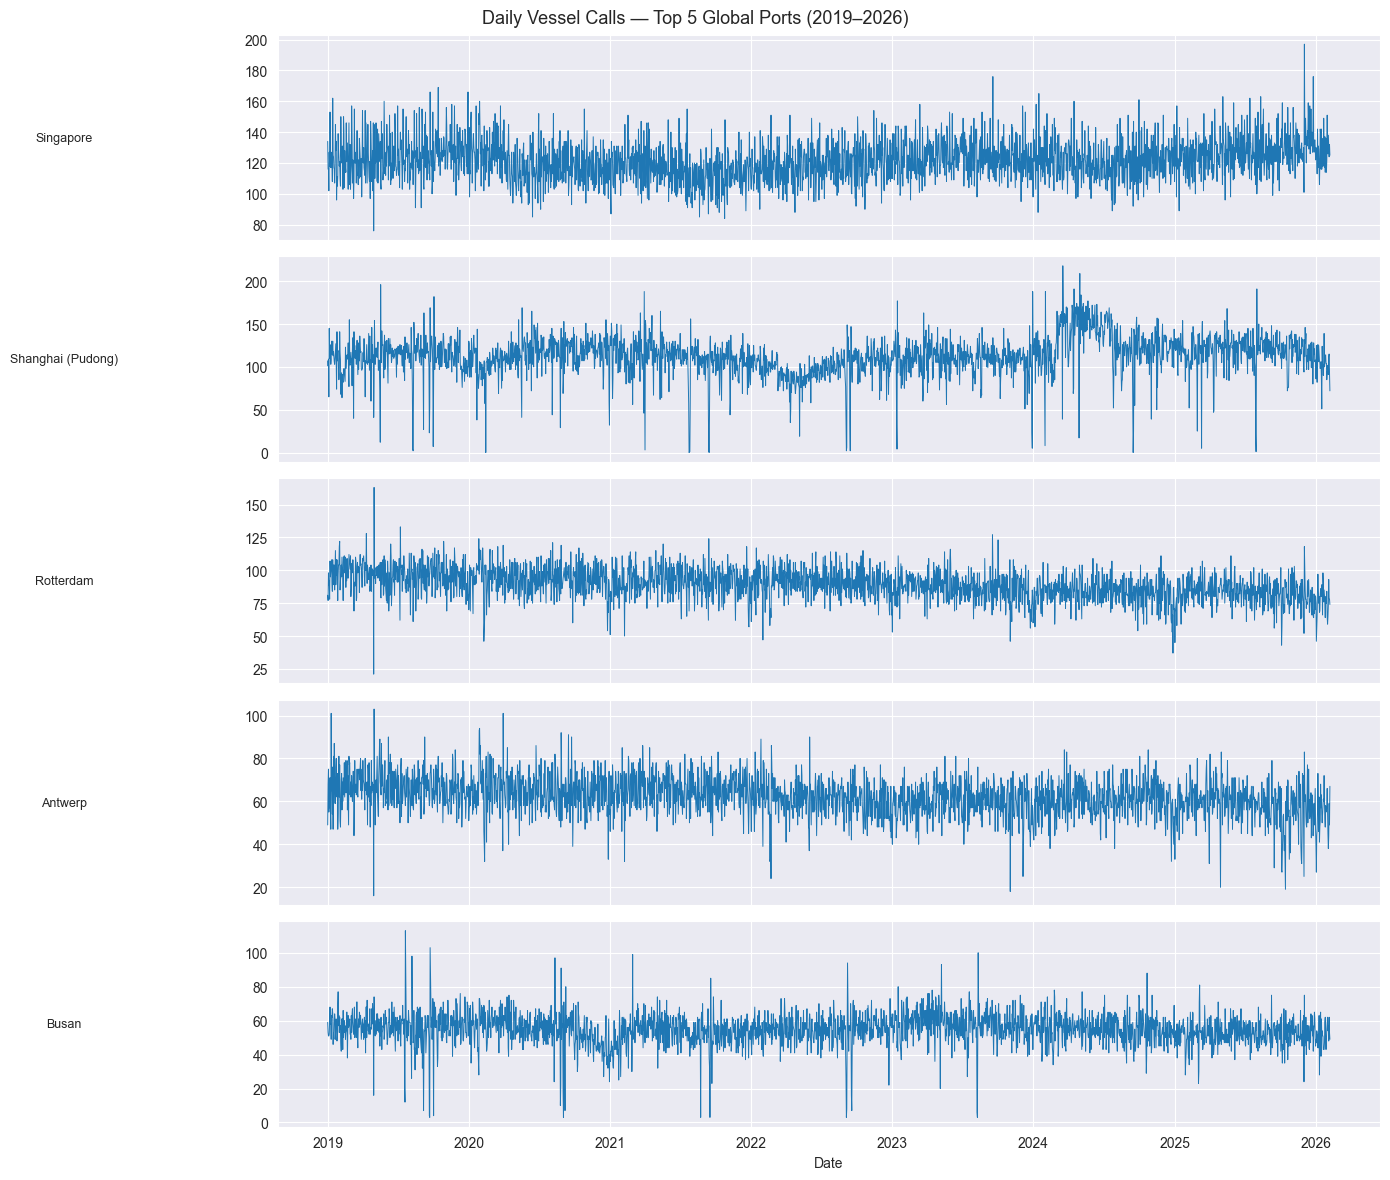

In [18]:
## Top 5 ports portcalls throughout the years
port_ts = df_top.pivot_table(
    index='date', columns='portname', values='portcalls', aggfunc='sum'
)

showcase = top_ports[:5]

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Daily Vessel Calls — Top 5 Global Ports (2019–2026)", fontsize=13)

for ax, port in zip(axes, showcase):
    ax.plot(port_ts.index, port_ts[port], linewidth=0.7)
    ax.set_ylabel(port, fontsize=9, rotation=0, labelpad=130, va='center')

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("../outputs/figures/01_port_trends.png", dpi=150, bbox_inches='tight')
plt.show()

## Defining the Port Disruption Event (PDE)
A Port Disruption Event (PDE) is a day when a port's vessel call count
falls more than 1.5 standard deviations below its own 30-day rolling mean.

Why 1.5 standard deviations?
- 1 std would be too sensitive — flagging normal variation
- 2 std would be too strict — missing real events
- 1.5 is a balanced threshold standard in anomaly detection literature

In [19]:
date_range = pd.date_range(df_top['date'].min(), df_top['date'].max(), freq="D")
date_range.tolist()

[Timestamp('2019-01-01 00:00:00'),
 Timestamp('2019-01-02 00:00:00'),
 Timestamp('2019-01-03 00:00:00'),
 Timestamp('2019-01-04 00:00:00'),
 Timestamp('2019-01-05 00:00:00'),
 Timestamp('2019-01-06 00:00:00'),
 Timestamp('2019-01-07 00:00:00'),
 Timestamp('2019-01-08 00:00:00'),
 Timestamp('2019-01-09 00:00:00'),
 Timestamp('2019-01-10 00:00:00'),
 Timestamp('2019-01-11 00:00:00'),
 Timestamp('2019-01-12 00:00:00'),
 Timestamp('2019-01-13 00:00:00'),
 Timestamp('2019-01-14 00:00:00'),
 Timestamp('2019-01-15 00:00:00'),
 Timestamp('2019-01-16 00:00:00'),
 Timestamp('2019-01-17 00:00:00'),
 Timestamp('2019-01-18 00:00:00'),
 Timestamp('2019-01-19 00:00:00'),
 Timestamp('2019-01-20 00:00:00'),
 Timestamp('2019-01-21 00:00:00'),
 Timestamp('2019-01-22 00:00:00'),
 Timestamp('2019-01-23 00:00:00'),
 Timestamp('2019-01-24 00:00:00'),
 Timestamp('2019-01-25 00:00:00'),
 Timestamp('2019-01-26 00:00:00'),
 Timestamp('2019-01-27 00:00:00'),
 Timestamp('2019-01-28 00:00:00'),
 Timestamp('2019-01-

In [20]:
## Defining the Port Disruption Event (PDE)
ROLLING_WINDOW = 30
STD_THRESHOLD  = 1.5

pde_results = {}

for port in top_ports:
    s = df_top[df_top['portname'] == port].set_index('date')['portcalls']


    mean = s.rolling(ROLLING_WINDOW, min_periods=15).mean()
    std  = s.rolling(ROLLING_WINDOW, min_periods=15).std()

    pde_results[port] = (s < mean - STD_THRESHOLD * std).astype(int)

pde_df = pd.DataFrame(pde_results)

print(f"PDE rate per port (% of days flagged):\n")
print((pde_df.mean()*100).round(2).sort_values(ascending=False).to_string())

# s = s.reindex(date_range).ffill(limit=3)

PDE rate per port (% of days flagged):

Ningbo                   8.33
Nagoya                   8.17
Qingdao                  7.98
Shanghai (Pudong)        7.86
Kobe                     7.79
Chiba                    7.56
Yokohama                 7.36
Tianjin Xin Gang         7.21
Kaohsiung                7.05
Busan                    6.98
Port Klang               6.98
Antwerp                  6.94
Guangzhou (Nansha)       6.94
Sakai-Semboku            6.94
Rotterdam                6.71
Mizushima                6.59
Hong Kong                6.36
Gwangyang (Kwangyang)    5.94
Ulsan                    5.28
Singapore                4.90


### What We Found — PDE Rates
The PDE rates vary by port. Some ports flag more days than others.
This variation is itself a finding: some ports are inherently more volatile.

* When do these PDEs occur and do they align with known real events?


In [22]:
## Validating the PDE Variable Against Real Events
disruption['fromdate'] = pd.to_datetime(disruption['fromdate'], dayfirst=False)
disruption.head()

,eventid,eventtype,eventname,htmlname,htmldescription,alertlevel,country,fromdate,year,todate,...,lat,long,editdate,affectedports,n_affectedports,affectedpopulation,pageid,ObjectId,Shape__Area,Shape__Length
0,1000552,TC,IDAI-19,Tropical Cyclone IDAI-19,"Red Tropical Cyclone IDAI-19 in Mozambique, Zi...",RED,Mozambique,2019-03-09 06:00:00,2019,3/15/2019 12:00:00 AM,...,-19.6000,34.800,9/10/2023 1:47:19 AM,port137,1,1.9 million in Category 1 or higher,3aa1164d42fb42e99f8ed581b6ecd4d1,1,3.500007e+11,3.223230e+06
1,1000227,FL,Flood in Mozambique,Flood in Mozambique,Red Flood in Mozambique from: 09 Mar 2019 00 t...,RED,Mozambique,2019-03-09 00:00:00,2019,3/29/2019 12:00:00 AM,...,-15.1780,36.432,9/10/2023 1:49:27 AM,port137; port784; port896,3,NaN,c2ad419a75d24ec28ae55a0728a0eb79,2,6.425900e+11,5.359811e+06
2,1000559,TC,KENNETH-19,Tropical Cyclone KENNETH-19,"Red Tropical Cyclone KENNETH-19 in , Mozambiqu...",RED,Mozambique; Comoros,2019-04-23 00:00:00,2019,4/25/2019 6:00:00 PM,...,-12.3000,40.100,9/10/2023 1:53:22 AM,port896; port769,2,260 thousand in Category 1 or higher,74c5908f37dd496caedc335fc2bcf6e1,3,2.263530e+11,2.574508e+06
3,1000561,TC,FANI-19,Tropical Cyclone FANI-19,"Red Tropical Cyclone FANI-19 in , India, Bangl...",RED,India,2019-04-27 00:00:00,2019,5/3/2019 12:00:00 PM,...,21.3000,86.200,9/10/2023 1:54:47 AM,port290; port883,2,1.8 million in Category 1 or higher,7a4e3ee5892f497a996870d3e0e6f414,4,5.600202e+11,4.851356e+06
4,1178759,EQ,"Earthquake in Eastern New Guinea Reg., P.N.G.","Earthquake in Eastern New Guinea Reg., P.N.G.",Red M 7.2 Earthquake in Eastern New Guinea Reg...,RED,Papua New Guinea,2019-05-06 21:19:35,2019,5/6/2019 9:19:35 PM,...,-6.9767,146.440,9/10/2023 1:55:14 AM,port624,1,NaN,98299d6738574f2ea18e46e19f71327e,5,3.206445e+10,6.348622e+05


In [23]:
major_events = disruption[
    (disruption['alertlevel'] == 'RED')&
    (disruption['fromdate'] >= '2020-01-01')&
    (disruption['fromdate'] <= '2026-01-01')
].sort_values('fromdate')

print(f"RED-level events in window: {len(major_events)}")
print(disruption['eventtype'].value_counts().to_string())

RED-level events in window: 106
eventtype
TC    71
EQ    29
FL    14
OT     5
DR     4
VO     2
WF     2


### Is There a Contagion Pattern?

Visual check first. Then statistical tests.
We plot PDE timelines for all 20 ports as a heatmap.
Each row = one port. Each column = one day.
Dark = PDE. Light = normal.

Vertical stripes = simultaneous disruption (common cause).
Diagonal patterns = cascade (contagion).

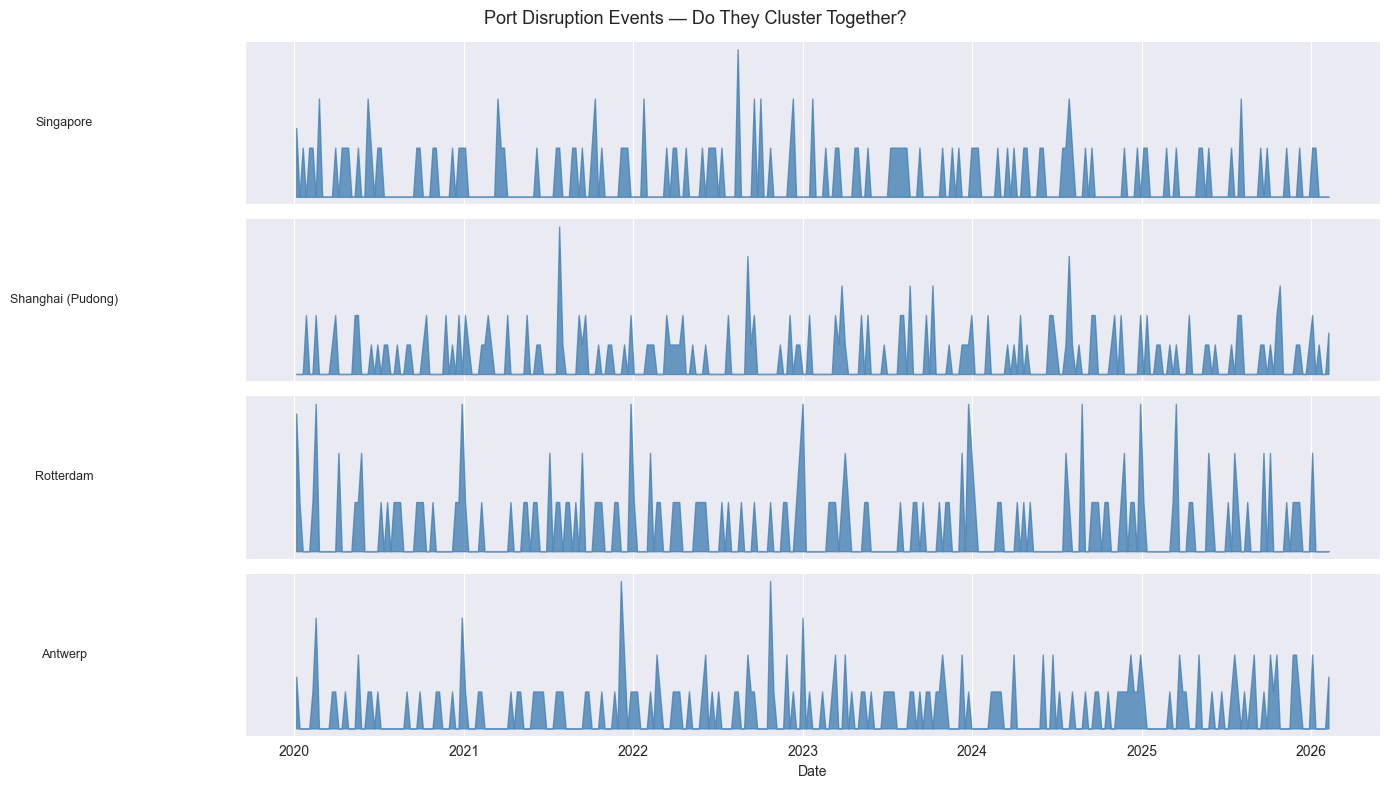

In [29]:
focus = top_ports[:4]

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Port Disruption Events — Do They Cluster Together?", fontsize=13)

for ax, port in zip(axes, focus):
    series = (
        pde_df[port][pde_df.index >= '2020-01-01']
        .resample('W').mean()  # % of days in that week flagged as PDE
    )
    ax.fill_between(series.index, series.values, alpha=0.8, color='steelblue')
    ax.set_ylabel(port, fontsize=9, rotation=0, labelpad=130, va='center')
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("../outputs/figures/03_pde_pattern.png", dpi=150, bbox_inches='tight')
plt.show()

* Early 2020 — all 4 ports spike simultaneously. That's the COVID. Classic common-cause disruption. All ports hit at the same time by the same global shock.
* 2021–2022 — peaks are less aligned. Singapore spikes around mid-2022, Rotterdam and Antwerp spike slightly later. This is where contagion might exist — the timing is staggered, not simultaneous.
* Shanghai (Pudong) behaves differently from the rest — its spikes are sharper and more isolated. This is consistent with China-specific events (COVID zero-policy lockdowns in 2022) rather than global network effects.
* Rotterdam and Antwerp move together — they're geographically close and serve the same European trade corridor. If one is disrupted, the other often follows quickly.
* No single dominant pattern — some periods look simultaneous (common cause), some look staggered (possible contagion).

## Cross-Port Lead-Lag — Does One Port Lead Another?

* Based on the above graph. We can conclude that some ports spike before others.
* For each pair of ports, we compute the correlation between two ports PDE series.

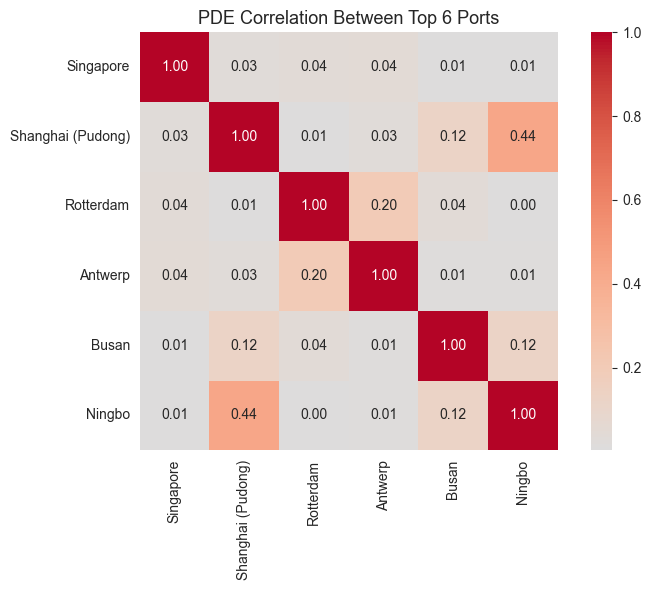

In [33]:
# Correlation matrix at lag 0 — do ports move together at all?
focus_ports = top_ports[:6]
corr_matrix = pde_df[focus_ports].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True)
ax.set_title("PDE Correlation Between Top 6 Ports", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/04_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

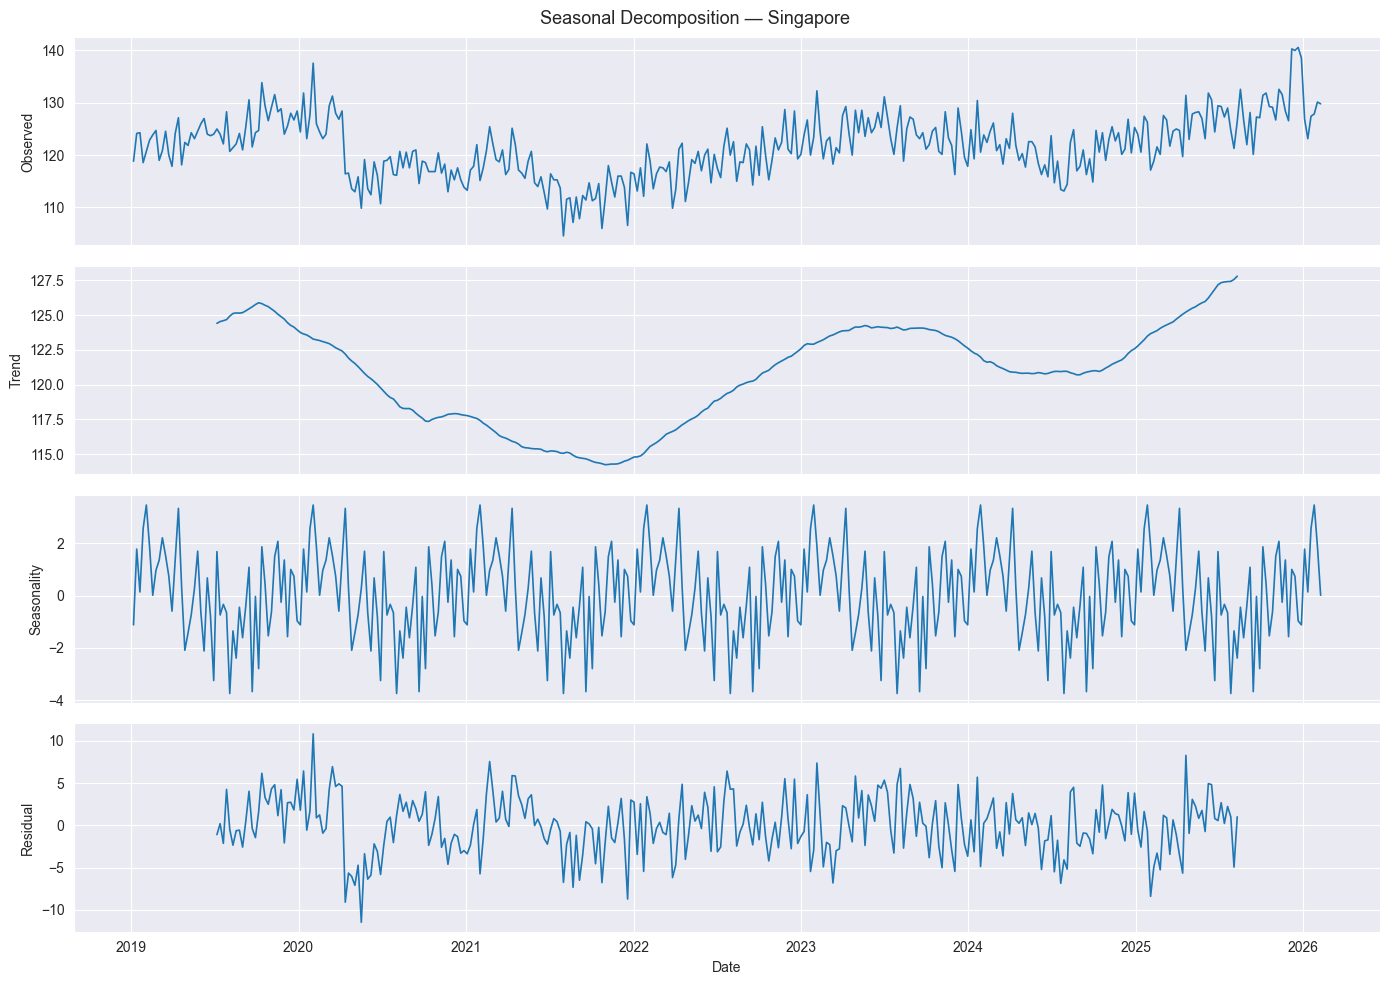

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

port_series = (
    df_top[df_top['portname'] == top_ports[0]]
    .set_index('date')['portcalls']
    .resample('W').mean()
    .dropna()
)

result = seasonal_decompose(port_series, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"Seasonal Decomposition — {top_ports[0]}", fontsize=13)

for ax, data, label in zip(axes,
    [port_series, result.trend, result.seasonal, result.resid],
    ["Observed", "Trend", "Seasonality", "Residual"]):
    ax.plot(data.index, data.values, linewidth=1.2)
    ax.set_ylabel(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("../outputs/figures/05_decomposition.png", dpi=150, bbox_inches='tight')
plt.show()

### What We Found — Seasonal Structure of Singapore

**Trend:** Singapore's vessel traffic peaked in early 2020, dropped through
2021–2022 as COVID disrupted global trade, bottomed out around mid-2022,
and has been recovering steadily since.

**Seasonality:** The seasonal component oscillates between roughly -4 and +3
vessel calls per week. Compared to observed values of 110–140, this is small.
Singapore is a transshipment hub operating year-round — Chinese New Year
barely registers as a seasonal dip.

In [35]:
pde_df.index.name = 'date'
pde_df.to_csv("../outputs/processed/pde_flags.csv")
port_ts.to_csv("../outputs/processed/port_activity_top20.csv")

print(f"pde_flags shape        : {pde_df.shape}")
print(f"port_activity shape    : {port_ts.shape}")

pde_flags shape        : (2594, 20)
port_activity shape    : (2594, 20)
